# CSI4142 - Assignment 4 (Unsupervised Learning)

**Group number:** 76
- **Student 1:** Peter Bou-Farah - 300295193  
- **Student 2:** Martin Patrouchev - 300286634

**Work Split:**
- **Peter Bou-Farah:** Study 1
- **Martin Patrouchev:** Study 2-4

## Dataset Description

**Dataset:** [The Movies Dataset](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset)  
**Author / source:** Rounak Banik (Kaggle); metadata sourced from [The Movie Database (TMDB)](https://www.themoviedb.org/).

**Purpose:** Built for recommender-system research and teaching: it combines movie metadata (text and numeric attributes) with user–movie ratings, supporting both content-based and collaborative approaches.

**Files used:**
- `movies_metadata.csv` — one row per movie; used for Studies 1–3 (similarity, clustering, content-based).
- `ratings_small.csv` — one row per rating (`userId`, `movieId`, `rating`, `timestamp`); used for Study 4 (utility matrix / matrix factorization).

**Shape (raw, after loading):** on the order of **~45k × ~24** for movies and **~100k ratings × 4** columns for `ratings_small`. Exact counts print in the load cell; cleaning (e.g. invalid ids, parsing genres) may drop a few movie rows.

**Why this dataset:** It is suggested in the assignment, is public on Kaggle with a stable link, and includes both metadata and per-user ratings, as required for Studies 1–3 vs Study 4.


In [34]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import pairwise_distances, silhouette_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")

In [35]:
# Get movies metadata
movies_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "rounakbanik/the-movies-dataset",
    "movies_metadata.csv",
)

# Get ratings data
ratings_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "rounakbanik/the-movies-dataset",
    "ratings_small.csv",
)

print("movies shape:", movies_raw.shape)
print("ratings shape:", ratings_raw.shape)
movies_raw.head(2)

movies shape: (45466, 24)
ratings shape: (100004, 4)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', 'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg', 'backdrop_path': '/...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afrai...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",NaN,8844,tt0113497,en,Jumanji,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwitting...",...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Français'}]",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0


# Data Preparation and EDA

In [36]:
def parse_genres(genres_text):
    if pd.isna(genres_text):
        return []
    # Parse the genres_text string into a Python list/dict
    parsed = ast.literal_eval(genres_text)
    if isinstance(parsed, list):
        return [d.get("name", "") for d in parsed if isinstance(d, dict)]
    return []


movies = movies_raw.copy()
ratings = ratings_raw.copy()

# Coerce selected columns to numeric
numeric_cols = ["id", "budget", "revenue", "runtime", "popularity", "vote_average", "vote_count"]
for col in numeric_cols:
    movies[col] = pd.to_numeric(movies[col], errors="coerce")

# Convert release_date to datetime
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year

# Parse genres into a list
movies["genres_list"] = movies["genres"].apply(parse_genres)
movies["genre_set"] = movies["genres_list"].apply(set)

# Drop duplicate movies based on 'id'
movies = movies.drop_duplicates(subset=["id"]).reset_index(drop=True)

# Fill missing titles and remove empty titles
movies["title"] = movies["title"].fillna("").str.strip()
movies = movies[movies["title"] != ""].copy()

# Feature list for report
feature_info = pd.DataFrame({
    "feature": movies.columns,
    "dtype": movies.dtypes.astype(str).values
})

print("Cleaned movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
feature_info.head(15)

Cleaned movies shape: (45430, 27)
Ratings shape: (100004, 4)


,feature,dtype
0,adult,object
1,belongs_to_collection,object
2,budget,float64
3,genres,object
4,homepage,object
5,id,float64
6,imdb_id,object
7,original_language,object
8,original_title,object
9,overview,object


### Main Features

| Feature | Description | Type |
|---|---|---|
| `title` | Movie title | Text |
| `genres` / `genres_list` | Movie genres (JSON-like raw -> parsed list) | Categorical |
| `budget` | Production budget | Numerical |
| `revenue` | Movie revenue | Numerical |
| `runtime` | Movie duration in minutes | Numerical |
| `popularity` | TMDB popularity score | Numerical |
| `vote_average` | Average user score | Numerical |
| `vote_count` | Number of votes | Numerical |
| `release_date` / `release_year` | Release date/year | Temporal |
| `id` | Movie identifier used to join ratings | Identifier |



In [37]:
# Check missing values 
missing_pct = (movies.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({"missing_%": missing_pct.round(2)})
missing_summary.head(12)

,missing_%
belongs_to_collection,90.12
homepage,82.89
tagline,55.09
overview,2.10
poster_path,0.84
runtime,0.57
release_year,0.18
release_date,0.18
status,0.18
imdb_id,0.04


In [38]:
# data type validation on main numeric features
validation_cols = ["budget", "revenue", "runtime", "popularity", "vote_average", "vote_count", "id"]
dtype_check = pd.DataFrame({
    "dtype": movies[validation_cols].dtypes.astype(str),
    "non_null_count": movies[validation_cols].notna().sum(),
    "null_count": movies[validation_cols].isna().sum()
})
dtype_check

,dtype,non_null_count,null_count
budget,float64,45430,0
revenue,float64,45430,0
runtime,float64,45173,257
popularity,float64,45430,0
vote_average,float64,45430,0
vote_count,float64,45430,0
id,float64,45430,0


In [39]:
# Outlier detection with IQR rule on main numerical columns
outlier_cols = ["budget", "revenue", "runtime", "popularity"]
outlier_rows = []
for col in outlier_cols:
    s = movies[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count_outliers = ((s < low) | (s > high)).sum()
    outlier_rows.append({
        "feature": col,
        "Q1": round(float(q1), 3),
        "Q3": round(float(q3), 3),
        "IQR": round(float(iqr), 3),
        "outlier_count": int(count_outliers),
        "outlier_%": round(100 * count_outliers / len(s), 2)
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,feature,Q1,Q3,IQR,outlier_count,outlier_%
0,budget,0.000,0.000,0.000,8880,19.55
1,revenue,0.000,0.000,0.000,7398,16.28
2,runtime,85.000,107.000,22.000,5416,11.99
3,popularity,0.386,3.678,3.292,4234,9.32


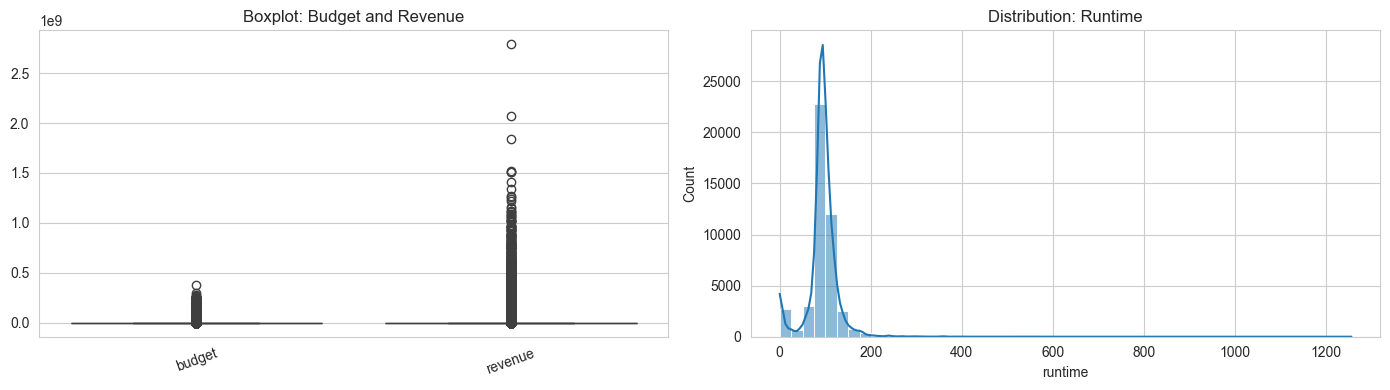

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=movies[["budget", "revenue"]], ax=axes[0])
axes[0].set_title("Boxplot: Budget and Revenue")
axes[0].tick_params(axis='x', rotation=20)

sns.histplot(movies["runtime"].dropna(), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution: Runtime")

plt.tight_layout()
plt.show()

Budget/revenue contain strong outliers, so we will standardize the features before distance-based methods.

## Study 1 - Similarity Measures

We implement the following similarity measures:
- Cosine (numerical)
- Euclidean (numerical)
- Jaccard (categorical)
- Levenshtein Distance (string)

We sort by popularity if the similarity score is the same.

In [41]:
def get_movie_row(df, title):
    t = title.strip().lower()
    match = df[df["title"].str.lower() == t]
    if len(match) == 0:
        alt = df[df["title"].str.lower() == f"the {t}"]
        if len(alt) == 1:
            match = alt
    if len(match) == 0:
        raise ValueError(f"Movie '{title}' not found.")
    return match.iloc[0]

# Jaccard similarity
def jaccard_similarity(a, b):
    if not a and not b:
        return 1.0
    union = len(a.union(b))
    if union == 0:
        return 0.0
    return len(a.intersection(b)) / union

# Levenshtein distance
def levenshtein_distance(s1, s2):
    s1 = str(s1)
    s2 = str(s2)
    if s1 == s2:
        return 0
    if len(s1) == 0:
        return len(s2)
    if len(s2) == 0:
        return len(s1)

    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1, start=1):
        curr = [i]
        for j, c2 in enumerate(s2, start=1):
            ins = curr[j - 1] + 1
            delete = prev[j] + 1
            sub = prev[j - 1] + (c1 != c2)
            curr.append(min(ins, delete, sub))
        prev = curr
    return prev[-1]


def normalized_edit_similarity(s1, s2):
    max_len = max(len(str(s1)), len(str(s2)))
    if max_len == 0:
        return 1.0
    return 1.0 - (levenshtein_distance(s1, s2) / max_len)

# Distance-based Top 10 on any numeric columns passed in `features`.
def top10_similar_numerical(df, query_title, features, metric):
    need = list(dict.fromkeys(list(features) + ["title"]))
    work = df.dropna(subset=need).copy().reset_index(drop=True)
    query_row = get_movie_row(work, query_title)
    q_idx = query_row.name
    q_canon = str(query_row["title"]).lower()

    X = work[list(features)].values
    # If cosine, scale to [0,1], else scale to standard normal
    if metric == "cosine":
        X_scaled = MinMaxScaler().fit_transform(X)
    else:
        X_scaled = StandardScaler().fit_transform(X)

    d = pairwise_distances(X_scaled, X_scaled[[q_idx]], metric=metric).ravel()
    dist_col = f"{metric}_distance"

    base = ["title", "release_year", "genres_list", "popularity"]
    view_cols = list(dict.fromkeys(base + list(features)))
    out = work[view_cols].copy()
    out[dist_col] = d
    out = out[out["title"].str.lower() != q_canon]
    # Sort by distance, then popularity
    return out.sort_values([dist_col, "popularity"], ascending=[True, False]).head(10)

# Jaccard similarity on parsed genre sets.
def top10_similar_jaccard_genres(df, query_title):
    work = df[df["genre_set"].apply(len) > 0].copy()
    q = get_movie_row(work, query_title)
    q_set = q["genre_set"]
    q_canon = str(q["title"]).lower()

    out = work[["title", "release_year", "genres_list", "runtime", "popularity", "budget", "revenue"]].copy()
    out["jaccard_similarity"] = work["genre_set"].apply(lambda s: jaccard_similarity(q_set, s))
    out = out[out["title"].str.lower() != q_canon]
    return out.sort_values(["jaccard_similarity", "popularity"], ascending=[False, False]).head(10)

# Normalized title similarity from Levenshtein.
def top10_similar_levenshtein_title(df, query_title):
    work = df.dropna(subset=["title"]).copy()
    query_row = get_movie_row(work, query_title)
    q_canon = str(query_row["title"]).lower()

    out = work[["title", "release_year", "genres_list", "runtime", "popularity", "budget", "revenue"]].copy()
    out["title_edit_similarity"] = out["title"].apply(
        lambda t: normalized_edit_similarity(query_row["title"].lower(), str(t).lower())
    )
    out = out[out["title"].str.lower() != q_canon]
    return out.sort_values(["title_edit_similarity", "popularity"], ascending=[False, False]).head(10)


In [42]:
print("Show me movies of the same genre as 'Toy Story' (Jaccard on genres)")
display(top10_similar_jaccard_genres(movies, "Toy Story"))

print("Show me movies with similar revenue to 'Titanic' (Euclidean on ['revenue'])")
display(top10_similar_numerical(movies, "Titanic", ["revenue"], metric="euclidean"))

print("Show me movies with similar length as 'Apollo 13' (Euclidean on ['runtime'] — duration)")
display(top10_similar_numerical(movies, "Apollo 13", ["runtime"], metric="euclidean"))

print("Show me movies with similar title to 'Fight Club' (Levenshtein / edit distance)")
display(top10_similar_levenshtein_title(movies, "Fight Club"))

print("Show me movies with similar budget to 'Matrix' (Euclidean on ['budget']; resolves to 'The Matrix' if needed)")
display(top10_similar_numerical(movies, "Matrix", ["budget"], metric="euclidean"))


Show me movies of the same genre as 'Toy Story' (Jaccard on genres)


,title,release_year,genres_list,runtime,popularity,budget,revenue,jaccard_similarity
45108,The Emoji Movie,2017.0,"[Comedy, Family, Animation]",86.0,33.694599,50000000.0,6.691394e+07,1.0
4755,"Monsters, Inc.",2001.0,"[Animation, Comedy, Family]",92.0,26.419962,115000000.0,5.628163e+08,1.0
21150,Despicable Me 2,2013.0,"[Animation, Comedy, Family]",98.0,24.823550,76000000.0,9.707619e+08,1.0
10517,Chicken Little,2005.0,"[Animation, Family, Comedy]",81.0,18.584609,150000000.0,3.144327e+08,1.0
2996,Toy Story 2,1999.0,"[Animation, Comedy, Family]",92.0,17.547693,90000000.0,4.973669e+08,1.0
15342,Toy Story 3,2010.0,"[Animation, Family, Comedy]",103.0,16.966470,200000000.0,1.066970e+09,1.0
21768,Cloudy with a Chance of Meatballs 2,2013.0,"[Animation, Family, Comedy]",95.0,14.412061,78000000.0,2.483846e+08,1.0
11956,The Simpsons Movie,2007.0,"[Animation, Comedy, Family]",87.0,14.302911,75000000.0,5.270689e+08,1.0
6794,Looney Tunes: Back in Action,2003.0,"[Animation, Comedy, Family]",90.0,13.666488,80000000.0,6.851484e+07,1.0
42206,The Boss Baby,2017.0,"[Animation, Comedy, Family]",97.0,13.392824,125000000.0,4.988149e+08,1.0


Show me movies with similar revenue to 'Titanic' (Euclidean on ['revenue'])


,title,release_year,genres_list,popularity,revenue,euclidean_distance
26536,Star Wars: The Force Awakens,2015.0,"[Action, Adventure, Science Fiction, Fantasy]",31.626013,2.068224e+09,3.468291
17810,The Avengers,2012.0,"[Science Fiction, Action, Adventure]",89.887648,1.519558e+09,5.057795
25065,Jurassic World,2015.0,"[Action, Adventure, Science Fiction, Thriller]",32.790475,1.513529e+09,5.151485
28810,Furious 7,2015.0,[Action],27.275687,1.506249e+09,5.264605
26539,Avengers: Age of Ultron,2015.0,"[Action, Adventure, Science Fiction]",37.379420,1.405404e+09,6.831714
17429,Harry Potter and the Deathly Hallows: Part 2,2011.0,"[Family, Fantasy, Adventure]",24.990737,1.342000e+09,7.816986
22095,Frozen,2013.0,"[Animation, Adventure, Family]",24.248243,1.274219e+09,8.870281
42189,Beauty and the Beast,2017.0,"[Family, Fantasy, Romance]",287.253654,1.262886e+09,9.046387
43222,The Fate of the Furious,2017.0,"[Action, Crime, Thriller]",48.573287,1.238765e+09,9.421228
20820,Iron Man 3,2013.0,"[Action, Adventure, Science Fiction]",23.721243,1.215440e+09,9.783687


Show me movies with similar length as 'Apollo 13' (Euclidean on ['runtime'] — duration)


,title,release_year,genres_list,popularity,runtime,euclidean_distance
44005,War for the Planet of the Apes,2017.0,"[Drama, Science Fiction, War]",146.161786,140.0,0.0
40924,Operation Mekong,2016.0,"[Action, Adventure]",35.972581,140.0,0.0
10113,Batman Begins,2005.0,"[Action, Crime, Drama]",28.505341,140.0,0.0
42622,The Lost City of Z,2016.0,"[Action, Adventure, Drama, History]",21.791111,140.0,0.0
40206,Hacksaw Ridge,2016.0,"[Drama, History, War]",21.037699,140.0,0.0
10060,Star Wars: Episode III - Revenge of the Sith,2005.0,"[Science Fiction, Adventure, Action]",13.165421,140.0,0.0
17802,Warrior,2011.0,"[Action, Drama]",13.121626,140.0,0.0
11749,La Vie en Rose,2007.0,"[Romance, Music, Drama]",11.710507,140.0,0.0
15476,The Karate Kid,2010.0,"[Action, Adventure, Drama, Family]",11.690781,140.0,0.0
4078,Death on the Nile,1978.0,[Mystery],11.162277,140.0,0.0


Show me movies with similar title to 'Fight Club' (Levenshtein / edit distance)


,title,release_year,genres_list,runtime,popularity,budget,revenue,title_edit_similarity
38551,Flight Crew,2016.0,"[Drama, Action]",138.0,5.420460,10000000.0,27305571.0,0.636364
26225,Night Court,1932.0,"[Crime, Drama, Thriller]",92.0,0.144281,0.0,0.0,0.636364
33222,The Club,2015.0,[Drama],97.0,3.534068,0.0,52761.0,0.600000
22079,The Club,1994.0,[Horror],94.0,0.573367,0.0,0.0,0.600000
35581,The Club,1980.0,"[Drama, Comedy]",96.0,0.475739,0.0,0.0,0.600000
22982,Fightville,2011.0,[Documentary],85.0,0.439409,0.0,0.0,0.600000
43143,Female Fight Club,2017.0,"[Drama, Action]",90.0,3.796019,2000000.0,0.0,0.588235
10805,Eight Below,2006.0,"[Adventure, Drama, Family]",120.0,13.876881,40000000.0,120455994.0,0.545455
24666,Cougar Club,2007.0,[Comedy],93.0,5.556157,0.0,0.0,0.545455
23480,Flight 7500,2014.0,"[Thriller, Horror, Mystery]",97.0,5.265969,0.0,0.0,0.545455


Show me movies with similar budget to 'Matrix' (Euclidean on ['budget']; resolves to 'The Matrix' if needed)


,title,release_year,genres_list,popularity,budget,euclidean_distance
2842,Fight Club,1999.0,[Drama],63.869599,63000000.0,0.000000
11121,World Trade Center,2006.0,"[Drama, History, Thriller]",13.332102,63000000.0,0.000000
2290,Rambo III,1988.0,"[Action, Adventure, Thriller, War]",11.624866,63000000.0,0.000000
378,Wyatt Earp,1994.0,"[Drama, Action, Western]",9.277147,63000000.0,0.000000
16909,Hop,2011.0,"[Animation, Comedy, Family]",8.904488,63000000.0,0.000000
475,Jurassic Park,1993.0,"[Adventure, Science Fiction]",8.863776,63000000.0,0.000000
5346,Austin Powers in Goldmember,2002.0,"[Comedy, Crime, Science Fiction]",8.786653,63000000.0,0.000000
3820,Get Carter,2000.0,"[Action, Drama, Thriller, Crime]",6.047757,63600000.0,0.034427
33299,The Little Prince,2015.0,"[Adventure, Animation, Fantasy]",11.376954,64000000.0,0.057378
11101,Little Man,2006.0,"[Comedy, Crime]",7.067602,64000000.0,0.057378


## Study 2 - Clustering (KMeans and DBSCAN)

We cluster on 2 attribute combinations from Study 1:
1. `budget` vs `revenue`
2. `runtime` vs `popularity`

- K Values: `3`,`5`
- EPS Values: `0.15`, `0.3`
- Min Samples Values: `5`, `10`

Combination: budget_revenue
--------------------------------------------------
KMeans


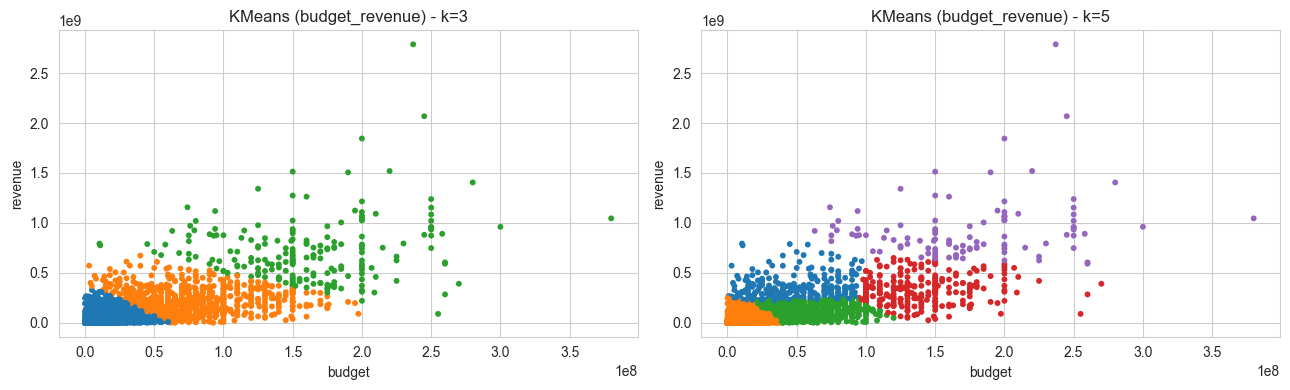

DBSCAN


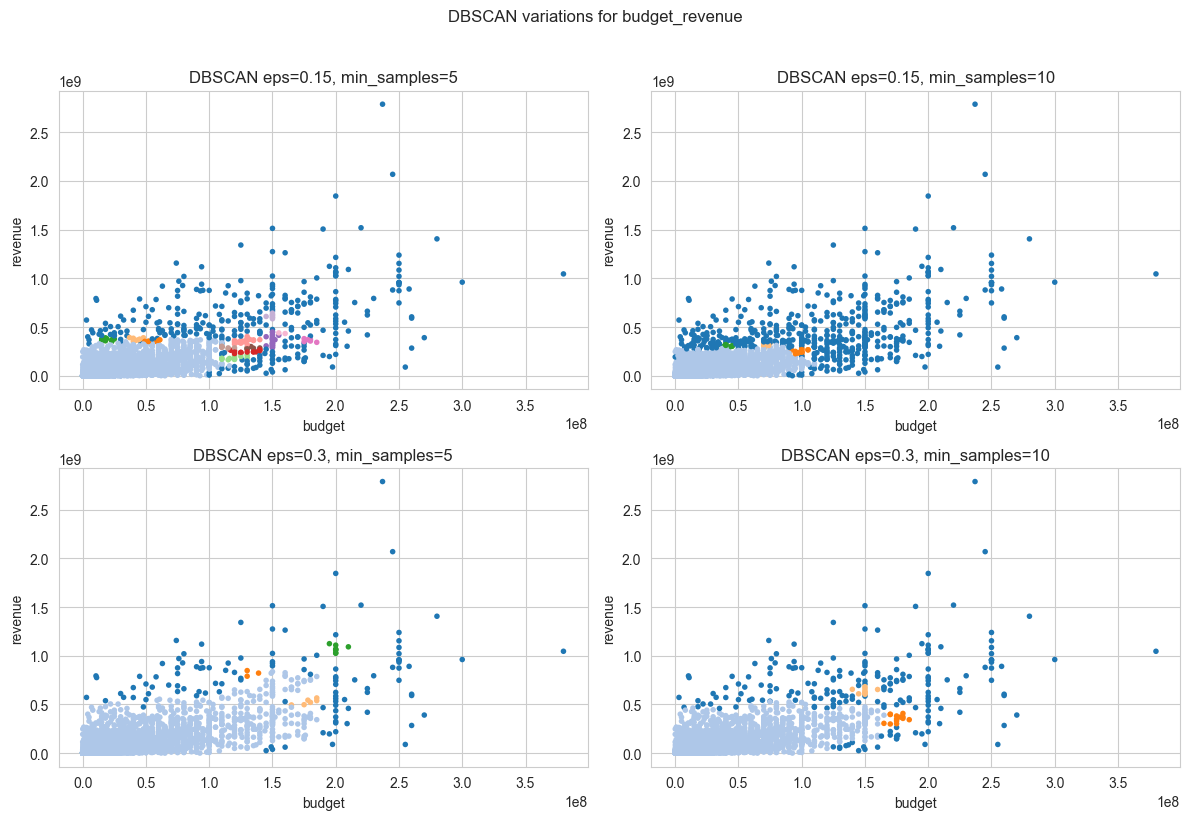

Combination: runtime_popularity
--------------------------------------------------
KMeans


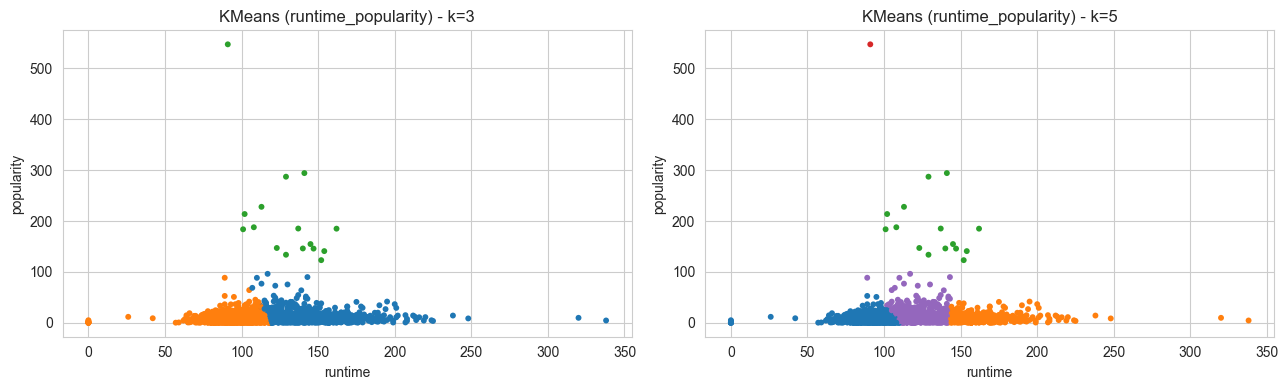

DBSCAN


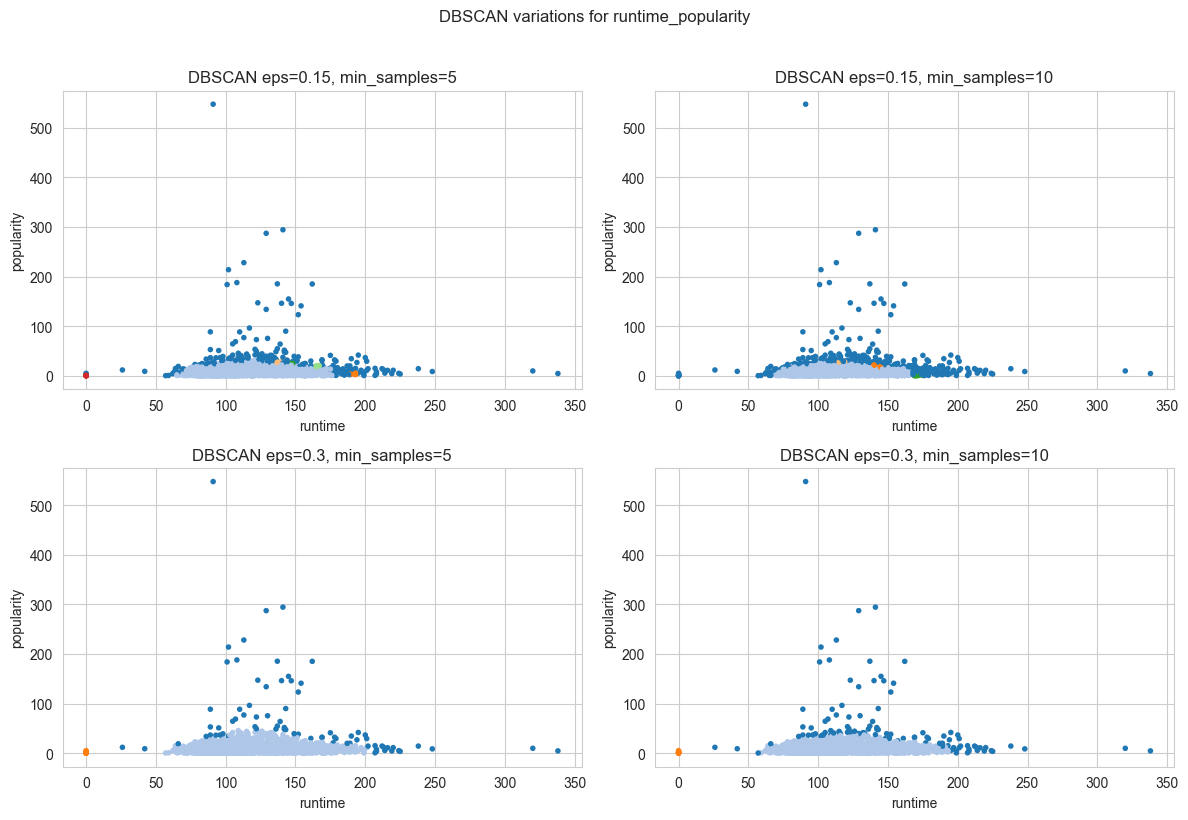

,combo,algorithm,params,n_clusters_found,noise_points,silhouette
0,budget_revenue,KMeans,k=3,3,0,0.6227
1,budget_revenue,KMeans,k=5,5,0,0.5641
2,budget_revenue,DBSCAN,"eps=0.15, min_samples=5",13,306,0.5169
3,budget_revenue,DBSCAN,"eps=0.15, min_samples=10",4,508,0.5159
4,budget_revenue,DBSCAN,"eps=0.3, min_samples=5",4,114,0.7296
5,budget_revenue,DBSCAN,"eps=0.3, min_samples=10",3,200,0.7287
6,runtime_popularity,KMeans,k=3,3,0,0.4940
7,runtime_popularity,KMeans,k=5,5,0,0.4299
8,runtime_popularity,DBSCAN,"eps=0.15, min_samples=5",6,202,0.4196
9,runtime_popularity,DBSCAN,"eps=0.15, min_samples=10",4,314,0.2654


In [43]:
cluster_base = movies.dropna(subset=["budget", "revenue", "runtime", "popularity"]).copy()

# Remove rows where all values are 0 for financial columns
cluster_base = cluster_base[(cluster_base["budget"] > 0) & (cluster_base["revenue"] > 0)]

combinations = {
    "budget_revenue": ["budget", "revenue"],
    "runtime_popularity": ["runtime", "popularity"]
}

# Values
k_values = [3, 5]
eps_values = [0.15, 0.30]
min_samples_values = [5, 10]

cluster_eval_rows = []

# For each combination
for combo_name, feats in combinations.items():
    print("Combination:", combo_name)
    print("-"*50)
    X = cluster_base[feats].values
    X_scaled = StandardScaler().fit_transform(X)

    # KMeans
    print("KMeans")
    fig, axes = plt.subplots(1, len(k_values), figsize=(13, 4))
    if len(k_values) == 1:
        axes = [axes]
    for ax, k in zip(axes, k_values):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="tab10", s=18, linewidth=0, ax=ax, legend=False)
        ax.set_title(f"KMeans ({combo_name}) - k={k}")
        ax.set_xlabel(feats[0])
        ax.set_ylabel(feats[1])

        sil = silhouette_score(X_scaled, labels) if len(np.unique(labels)) > 1 else np.nan
        cluster_eval_rows.append({
            "combo": combo_name,
            "algorithm": "KMeans",
            "params": f"k={k}",
            "n_clusters_found": int(len(np.unique(labels))),
            "noise_points": 0,
            "silhouette": round(float(sil), 4) if not np.isnan(sil) else np.nan
        })

    plt.tight_layout()
    plt.show()

    print("DBSCAN")
    # DBSCAN 
    fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(12, 8))
    for i, eps in enumerate(eps_values):
        for j, ms in enumerate(min_samples_values):
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X_scaled)

            ax = axes[i, j]
            sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="tab20", s=16, linewidth=0, ax=ax, legend=False)
            ax.set_title(f"DBSCAN eps={eps}, min_samples={ms}")
            ax.set_xlabel(feats[0])
            ax.set_ylabel(feats[1])

            cluster_labels = labels[labels != -1]
            n_clusters = len(np.unique(cluster_labels)) if len(cluster_labels) > 0 else 0
            noise = int((labels == -1).sum())

            if n_clusters > 1:
                sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
            else:
                sil = np.nan

            cluster_eval_rows.append({
                "combo": combo_name,
                "algorithm": "DBSCAN",
                "params": f"eps={eps}, min_samples={ms}",
                "n_clusters_found": int(n_clusters),
                "noise_points": noise,
                "silhouette": round(float(sil), 4) if not np.isnan(sil) else np.nan
            })

    plt.suptitle(f"DBSCAN variations for {combo_name}", y=1.02)
    plt.tight_layout()
    plt.show()

cluster_eval = pd.DataFrame(cluster_eval_rows)
cluster_eval

## Study 3 - Content-Based Recommendation

### Heuristic 1
- Assume users want similar **genre** and **consumption effort**.
- Score = weighted combination of:
  - Jaccard similarity on genres
  - Euclidean similarity on runtime and popularity

### Heuristic 2
- Assume users want movies with similar **genre** and **production scale**.
- Score = weighted combination of:
  - Jaccard similarity on genres
  - Euclidean similarity on budget and revenue

In [44]:
cb_df = movies.dropna(subset=["title", "runtime", "popularity", "budget", "revenue"]).copy()
cb_df = cb_df[(cb_df["runtime"] > 0) & (cb_df["budget"] > 0) & (cb_df["revenue"] >= 0)]
cb_df = cb_df.reset_index(drop=True)

# Precompute scaled spaces for fast distance computations
X_rp = StandardScaler().fit_transform(cb_df[["runtime", "popularity"]])
X_br_std = StandardScaler().fit_transform(cb_df[["budget", "revenue"]])
X_br_mm = MinMaxScaler().fit_transform(cb_df[["budget", "revenue"]])

# Heuristic 1 (Narrative Profile)
def content_reco_heuristic_1(query_title, top_n=10):
    q = get_movie_row(cb_df, query_title)
    q_idx = q.name

    # Euclidean distance to similarity
    d = pairwise_distances(X_rp, X_rp[[q_idx]], metric="euclidean").ravel()
    rp_sim = 1.0 / (1.0 + d)

    # Jaccard similarity on genres
    g_sim = cb_df["genre_set"].apply(lambda s: jaccard_similarity(q["genre_set"], s)).values

    # Weighted combination of genre and runtime/popularity similarity (60/40)
    score = 0.60 * g_sim + 0.40 * rp_sim

    out = cb_df[["title", "genres_list", "runtime", "popularity", "release_year", "budget"]].copy()
    out["score_h1"] = score
    out = out[out["title"].str.lower() != query_title.lower()]
    return out.sort_values(["score_h1", "popularity"], ascending=[False, False]).head(top_n)

# Heuristic 2 (Production Profile)
def content_reco_heuristic_2(query_title, top_n=10):
    q = get_movie_row(cb_df, query_title)
    q_idx = q.name

    # Euclidean distance to budget/revenue
    d_eu = pairwise_distances(X_br_std, X_br_std[[q_idx]], metric="euclidean").ravel()
    sim_eu = 1.0 / (1.0 + d_eu)

    # Jaccard similarity on genres
    g_sim = cb_df["genre_set"].apply(lambda s: jaccard_similarity(q["genre_set"], s)).values

    # Weighted combination of genre and budget/revenue similarity (60/40)
    score = 0.6 * g_sim + 0.4 * sim_eu 

    out = cb_df[["title", "genres_list", "budget", "revenue", "popularity", "release_year"]].copy()
    out["score_h2"] = score
    out = out[out["title"].str.lower() != query_title.lower()]
    return out.sort_values(["score_h2", "popularity"], ascending=[False, False]).head(top_n)

In [45]:
content_queries = ["Toy Story", "The Blair Witch Project", "Fight Club"]

for q in content_queries:
    print("-" * 50)
    print(f"Request: movies similar to '{q}'")
    print("Heuristic 1 - Narrative Feel")
    display(content_reco_heuristic_1(q, top_n=10))
    
    print("Heuristic 2 - Production Profile")
    display(content_reco_heuristic_2(q, top_n=10))

--------------------------------------------------
Request: movies similar to 'Toy Story'
Heuristic 1 - Narrative Feel


,title,genres_list,runtime,popularity,release_year,budget,score_h1
3627,Chicken Little,"[Animation, Family, Comedy]",81.0,18.584609,2005.0,150000000.0,0.909298
1394,Toy Story 2,"[Animation, Comedy, Family]",92.0,17.547693,1999.0,90000000.0,0.856456
2092,"Monsters, Inc.","[Animation, Comedy, Family]",92.0,26.419962,2001.0,115000000.0,0.855730
6109,Despicable Me 2,"[Animation, Comedy, Family]",98.0,24.823550,2013.0,76000000.0,0.838389
4075,The Simpsons Movie,"[Animation, Comedy, Family]",87.0,14.302911,2007.0,75000000.0,0.834912
2722,Looney Tunes: Back in Action,"[Animation, Comedy, Family]",90.0,13.666488,2003.0,80000000.0,0.822786
6225,Cloudy with a Chance of Meatballs 2,"[Animation, Family, Comedy]",95.0,14.412061,2013.0,78000000.0,0.817725
1660,Chicken Run,"[Animation, Comedy, Family]",84.0,11.834245,2000.0,45000000.0,0.811756
4045,Surf's Up,"[Animation, Comedy, Family]",85.0,11.526339,2007.0,85000000.0,0.808241
4984,Toy Story 3,"[Animation, Family, Comedy]",103.0,16.966470,2010.0,200000000.0,0.807948


Heuristic 2 - Production Profile


,title,genres_list,budget,revenue,popularity,release_year,score_h2
1660,Chicken Run,"[Animation, Comedy, Family]",45000000.0,224834564.0,11.834245,2000.0,0.784421
3006,Garfield,"[Animation, Comedy, Family]",50000000.0,200804534.0,10.003679,2004.0,0.767541
3755,Over the Hedge,"[Comedy, Animation, Family]",80000000.0,343397247.0,9.382953,2006.0,0.761991
7571,Hotel Transylvania 2,"[Animation, Comedy, Family]",80000000.0,473226958.0,11.760218,2015.0,0.752413
6225,Cloudy with a Chance of Meatballs 2,"[Animation, Family, Comedy]",78000000.0,248384621.0,14.412061,2013.0,0.749991
5279,Hop,"[Animation, Comedy, Family]",63000000.0,183953723.0,8.904488,2011.0,0.749103
3144,The SpongeBob SquarePants Movie,"[Animation, Comedy, Family]",30000000.0,140161792.0,11.213712,2004.0,0.748026
4075,The Simpsons Movie,"[Animation, Comedy, Family]",75000000.0,527068851.0,14.302911,2007.0,0.746986
1394,Toy Story 2,"[Animation, Comedy, Family]",90000000.0,497366869.0,17.547693,1999.0,0.734986
6262,Free Birds,"[Animation, Comedy, Family]",55000000.0,110000000.0,7.713231,2013.0,0.730938


--------------------------------------------------
Request: movies similar to 'The Blair Witch Project'
Heuristic 1 - Narrative Feel


...

,title,genres_list,budget,revenue,popularity,release_year,score_h2
4704,Paranormal Activity,"[Horror, Mystery]",15000.0,193355800.0,12.706424,2007.0,0.886011
727,Scream 2,"[Horror, Mystery]",24000000.0,172363301.0,11.264845,1997.0,0.811891
4500,My Bloody Valentine,"[Mystery, Horror]",15000000.0,100734718.0,5.245883,2009.0,0.785317
3685,Final Destination 3,"[Horror, Mystery]",25000000.0,117719158.0,11.872997,2006.0,0.782235
4694,The Final Destination,"[Horror, Mystery]",40000000.0,186167139.0,8.805723,2009.0,0.778175
1453,Scream 3,"[Horror, Mystery]",40000000.0,161834276.0,9.738371,2000.0,0.772438
4741,Saw VI,"[Horror, Mystery]",11000000.0,68233629.0,17.360894,2009.0,0.770278
2476,Final Destination 2,"[Horror, Mystery]",26000000.0,90426405.0,12.638573,2003.0,0.768468
2356,The Ring,"[Horror, Mystery]",48000000.0,249348933.0,13.740965,2002.0,0.767161
5411,Final Destination 5,"[Horror, Mystery]",47000000.0,157887643.0,12.912491,2011.0,0.759115


--------------------------------------------------
Request: movies similar to 'Fight Club'
Heuristic 1 - Narrative Feel


,title,genres_list,runtime,popularity,release_year,budget,score_h1
6533,Whiplash,[Drama],105.0,64.299990,2014.0,3300000.0,0.776979
484,One Flew Over the Cuckoo's Nest,[Drama],133.0,35.529554,1975.0,3000000.0,0.714887
7695,Creed,[Drama],133.0,33.449723,2015.0,37000000.0,0.709218
4474,Seven Pounds,[Drama],123.0,21.708267,2008.0,55000000.0,0.684663
1278,American Beauty,[Drama],122.0,20.726578,1999.0,15000000.0,0.683072
3805,The Pursuit of Happyness,[Drama],117.0,20.981716,2006.0,55000000.0,0.682845
521,Dead Poets Society,[Drama],129.0,19.905716,1989.0,16400000.0,0.682437
69,Apollo 13,[Drama],140.0,18.761467,1995.0,52000000.0,0.681065
1664,The Perfect Storm,[Drama],130.0,18.911961,2000.0,120000000.0,0.681051
6629,The Judge,[Drama],141.0,17.887943,2014.0,50000000.0,0.679824


Heuristic 2 - Production Profile


,title,genres_list,budget,revenue,popularity,release_year,score_h2
1413,Any Given Sunday,[Drama],55000000.0,100230832.0,10.571434,1999.0,0.924549
2186,Dragonfly,[Drama],60000000.0,52322400.0,4.924078,2002.0,0.893140
1086,A Civil Action,[Drama],70000000.0,56702901.0,9.353499,1998.0,0.889674
5448,Moneyball,[Drama],50000000.0,110206216.0,15.785663,2011.0,0.889056
6629,The Judge,[Drama],50000000.0,83719388.0,17.887943,2014.0,0.886155
3920,We Are Marshall,[Drama],65000000.0,43545364.0,5.401746,2006.0,0.881295
1418,The Hurricane,[Drama],50000000.0,73956241.0,5.716009,1999.0,0.880581
3922,Dreamgirls,[Drama],70000000.0,154937680.0,7.739633,2006.0,0.877046
4594,The Soloist,[Drama],60000000.0,31720158.0,11.328316,2009.0,0.864603
3850,The Black Dahlia,[Drama],50000000.0,49111202.0,6.506572,2006.0,0.860769


Heuristic 1 recommends movies with similar genres and viewing characteristics, such as duration and popularity.
 
Heuristic 2 recommends movies with comparable genres and production scale (budget/revenue), which tends to prioritize blockbusters.
 
For example, when testing with "The Blair Witch Project," Heuristic 1 suggested horror films that were also short and popular, whereas Heuristic 2 highlighted horror movies with low budgets but high revenues (essentially successful indie films).
 
Ultimately, deciding which heuristic provides more relevant recommendations can be subjective. However, based on these anecdotal queries, Heuristic 1 generally appears to deliver more relevant suggestions.

## Study 4 - Collaborative Filtering (Model-Based)

In [46]:
# Keep only ratings that can be mapped to movie titles in metadata
movie_lookup = movies[["id", "title"]].dropna().copy()
movie_lookup["id"] = movie_lookup["id"].astype(int)
ratings_cf = ratings.copy()
ratings_cf["movieId"] = pd.to_numeric(ratings_cf["movieId"], errors="coerce")
ratings_cf = ratings_cf.dropna(subset=["movieId", "userId", "rating"]).copy()
ratings_cf["movieId"] = ratings_cf["movieId"].astype(int)
ratings_cf["userId"] = ratings_cf["userId"].astype(int)
valid_movie_ids = set(movie_lookup["id"].unique())
ratings_cf = ratings_cf[ratings_cf["movieId"].isin(valid_movie_ids)].copy()

print("Ratings retained for CF:", ratings_cf.shape)
print("Unique users:", ratings_cf["userId"].nunique())
print("Unique movies:", ratings_cf["movieId"].nunique())

# Build 10% per-user gold standard split
def split_gold_standard(df, frac):
    rng = np.random.default_rng(42)
    test_parts = []
    train_parts = []

    # Group by user and split into train/test sets
    for _, g in df.groupby('userId'):
        n = len(g)
        if n < 2:
            train_parts.append(g)
            continue

        n_test = max(1, int(round(frac * n)))
        test_idx = rng.choice(g.index.to_numpy(), size=n_test, replace=False)

        test_parts.append(g.loc[test_idx])
        train_parts.append(g.drop(index=test_idx))

    train = pd.concat(train_parts).sort_index().reset_index(drop=True)
    test = pd.concat(test_parts).sort_index().reset_index(drop=True)
    return train, test

train_ratings, gold_standard = split_gold_standard(ratings_cf, frac=0.10)

print("Train shape:", train_ratings.shape)
print("Gold Standard shape:", gold_standard.shape)
print("GS ratio:", round(len(gold_standard) / len(ratings_cf), 4))

Ratings retained for CF: (44989, 4)
Unique users: 671
Unique movies: 2830
Train shape: (40485, 4)
Gold Standard shape: (4504, 4)
GS ratio: 0.1001


In [47]:
# Build index mappings
users = np.sort(train_ratings["userId"].unique())
items = np.sort(train_ratings["movieId"].unique())

u2i = {u: i for i, u in enumerate(users)}
m2i = {m: j for j, m in enumerate(items)}

global_mean = train_ratings["rating"].mean()

# Observed tuples for SGD
obs = train_ratings[["userId", "movieId", "rating"]].copy()
obs["u_idx"] = obs["userId"].map(u2i)
obs["m_idx"] = obs["movieId"].map(m2i)
obs = obs.dropna(subset=["u_idx", "m_idx"]).copy()
obs["u_idx"] = obs["u_idx"].astype(int)
obs["m_idx"] = obs["m_idx"].astype(int)

obs_arr = obs[["u_idx", "m_idx", "rating"]].to_numpy()

print("Utility matrix size (users x items):", (len(users), len(items)))
print("Known ratings in train:", len(obs_arr))

# Train Matrix Factorization with SGD
def train_mf_sgd(obs_array, n_users, n_items, k, epochs, lr, reg):
    rng = np.random.default_rng(42)
    P = rng.normal(0, 0.1, size=(n_users, k))
    Q = rng.normal(0, 0.1, size=(n_items, k))

    for _ in range(epochs):
        rng.shuffle(obs_array)
        for u_idx, m_idx, r in obs_array:
            u = int(u_idx)
            m = int(m_idx)
            pred = np.dot(P[u], Q[m])
            err = r - pred

            p_u = P[u].copy()
            q_m = Q[m].copy()

            P[u] += lr * (err * q_m - reg * p_u)
            Q[m] += lr * (err * p_u - reg * q_m)

    return P, Q


# Predict single rating
def predict_single(user_id, movie_id, P, Q):
    if user_id not in u2i or movie_id not in m2i:
        return global_mean
    return float(np.dot(P[u2i[user_id]], Q[m2i[movie_id]]))


# Calculate ranking metrics on gold standard
def ranking_metrics_on_gs(gs_df, P, Q, k_values=(5, 10), rel_threshold=4.0):
    user_groups = gs_df.groupby("userId")

    precisions = {k: [] for k in k_values}
    reciprocal_ranks = []

    for user, g in user_groups:
        # Evaluate ranking among withheld items for that user
        g = g.copy()
        g["pred"] = g["movieId"].apply(lambda m: predict_single(user, m, P, Q))
        g = g.sort_values("pred", ascending=False).reset_index(drop=True)

        rel = (g["rating"] >= rel_threshold).astype(int).to_numpy()
        if rel.sum() == 0:
            continue

        for k in k_values:
            topk = rel[:k]
            precisions[k].append(topk.sum() / k)

        rel_positions = np.where(rel == 1)[0]
        reciprocal_ranks.append(1.0 / (rel_positions[0] + 1))

    p_at_k = {f"P@{k}": float(np.mean(vals)) if len(vals) > 0 else np.nan for k, vals in precisions.items()}
    mrr = float(np.mean(reciprocal_ranks)) if len(reciprocal_ranks) > 0 else np.nan
    return p_at_k, mrr


latent_dims = [2, 5, 10, 20, 50, 100]
eval_rows = []
models = {}

# Train models with different latent dimensions
for k in latent_dims:
    P, Q = train_mf_sgd(obs_arr.copy(), len(users), len(items), k=k, epochs=14, lr=0.01, reg=0.05)
    models[k] = (P, Q)

    gs_pred = gold_standard.copy()
    gs_pred["pred_rating"] = gs_pred.apply(lambda r: predict_single(r["userId"], r["movieId"], P, Q), axis=1)

    mse = mean_squared_error(gs_pred["rating"], gs_pred["pred_rating"])
    p_scores, mrr = ranking_metrics_on_gs(gold_standard, P, Q, k_values=(5, 10), rel_threshold=4.0)

    eval_rows.append({
        "latent_dim": k,
        "MSE": round(float(mse), 4),
        "P@5": round(float(p_scores["P@5"]), 4),
        "P@10": round(float(p_scores["P@10"]), 4),
        "MRR": round(float(mrr), 4)
    })

eval_df = pd.DataFrame(eval_rows).sort_values("MSE")
eval_df

Utility matrix size (users x items): (671, 2743)
Known ratings in train: 40485


,latent_dim,MSE,P@5,P@10,MRR
1,5,0.9067,0.4928,0.3198,0.8961
2,10,0.9125,0.4931,0.3203,0.8949
3,20,0.9209,0.4972,0.3213,0.8945
0,2,0.9316,0.4891,0.3199,0.8889
4,50,0.9501,0.4955,0.3203,0.8980
5,100,0.9768,0.4955,0.3203,0.9006


In [48]:
# Evaluate metrics for rel_threshold=3.5 and 4.5:
eval_rows_35 = []
eval_rows_45 = []

for k in latent_dims:
    P, Q = models[k]
    # rel_threshold=3.5
    p_scores_35, mrr_35 = ranking_metrics_on_gs(gold_standard, P, Q, k_values=(5, 10), rel_threshold=3.5)
    eval_rows_35.append({
        "latent_dim": k,
        "P@5": round(float(p_scores_35["P@5"]), 4),
        "P@10": round(float(p_scores_35["P@10"]), 4),
        "MRR": round(float(mrr_35), 4)
    })
    # rel_threshold=4.5
    p_scores_45, mrr_45 = ranking_metrics_on_gs(gold_standard, P, Q, k_values=(5, 10), rel_threshold=4.5)
    eval_rows_45.append({
        "latent_dim": k,
        "P@5": round(float(p_scores_45["P@5"]), 4),
        "P@10": round(float(p_scores_45["P@10"]), 4),
        "MRR": round(float(mrr_45), 4)
    })

eval_df_35 = pd.DataFrame(eval_rows_35)
eval_df_45 = pd.DataFrame(eval_rows_45)

print("rel_threshold = 3.5")
display(eval_df_35)
print("rel_threshold = 4.5")
display(eval_df_45)

rel_threshold = 3.5


,latent_dim,P@5,P@10,MRR
0,2,0.5254,0.3498,0.9093
1,5,0.5303,0.3498,0.9195
2,10,0.5287,0.3502,0.9192
3,20,0.5316,0.3513,0.9171
4,50,0.5309,0.3508,0.9209
5,100,0.5322,0.3518,0.9191


rel_threshold = 4.5


,latent_dim,P@5,P@10,MRR
0,2,0.3447,0.2112,0.7811
1,5,0.3470,0.2128,0.7921
2,10,0.3474,0.2119,0.7846
3,20,0.3528,0.2142,0.7821
4,50,0.3479,0.2133,0.7891
5,100,0.3515,0.2139,0.7873


In [ ]:
# MSE is lowest at latent dimension 5
best_latent_dim = 5
P_best, Q_best = models[best_latent_dim]
print(f"Best latent dimension by MSE: {best_latent_dim}")

rated_by_user = train_ratings.groupby("userId")["movieId"].apply(set).to_dict()
id_to_title = dict(zip(movie_lookup["id"], movie_lookup["title"]))


def recommend_unseen(user_id, top_n=10):
    if user_id not in u2i:
        return pd.DataFrame(columns=["movieId", "title", "pred_rating"])

    seen = rated_by_user.get(user_id, set())
    candidates = [m for m in items if m not in seen]

    preds = []
    for m in candidates:
        preds.append((m, predict_single(user_id, m, P_best, Q_best)))

    recs = pd.DataFrame(preds, columns=["movieId", "pred_rating"]) \
        .sort_values("pred_rating", ascending=False) \
        .head(top_n)
    recs["title"] = recs["movieId"].map(id_to_title)
    return recs[["movieId", "title", "pred_rating"]]

# Simulate 3 user requests (users with most interactions)
top_active_users = train_ratings["userId"].value_counts().head(3).index.tolist()
print("Users selected for simulation:", top_active_users)

for uid in top_active_users:
    print(f"\n--- Top unseen recommendations for user {uid} ---")
    display(recommend_unseen(uid, top_n=10))

Best latent dimension by MSE: 5
Users selected for simulation: [564, 547, 15]

--- Top unseen recommendations for user 564 ---


,movieId,title,pred_rating
440,1948,Crank,5.212338
289,994,Straw Dogs,5.168408
433,1939,Laura,5.013552
163,608,Men in Black II,5.011728
256,926,Galaxy Quest,4.976496
438,1945,Nell,4.895957
1604,52767,The Hunter,4.842383
69,246,Zatoichi,4.820365
709,4226,Shriek If You Know What I Did Last Friday the Thirteenth,4.807439
95,307,"Rome, Open City",4.803454



--- Top unseen recommendations for user 547 ---


,movieId,title,pred_rating
325,608,Men in Black II,5.011666
512,1281,Bean,4.748720
469,950,Ice Age: The Meltdown,4.747219
18,58,Pirates of the Caribbean: Dead Man's Chest,4.681292
1074,3683,Flags of Our Fathers,4.639102
456,913,The Thomas Crown Affair,4.633814
505,1260,Lotte from Gadgetville,4.601371
319,595,To Kill a Mockingbird,4.530581
1807,55069,The Delivery,4.492659
1247,5147,The Lost Continent,4.466280



--- Top unseen recommendations for user 15 ---


,movieId,title,pred_rating
699,1939,Laura,3.961586
426,905,Pandora's Box,3.948214
706,1948,Crank,3.935896
422,898,Birdman of Alcatraz,3.921754
428,912,The Thomas Crown Affair,3.910248
474,994,Straw Dogs,3.894597
352,745,The Sixth Sense,3.864677
53,116,Match Point,3.857906
1019,3037,Yella,3.837259
533,1411,The Rapture,3.804301


### Discussion

The table above ranks latent sizes by **MSE on the 10% holdout**. In our run, **\(k=5\)** achieves the **lowest MSE (~0.907)**, so it generalizes best to unseen user–movie ratings under this setup (fixed epochs, learning rate, and regularization).

- **Underfitting (small \(k\)):** **\(k=2\)** has **higher MSE (~0.932)** than \(k=5\). Too few latent factors limit what the model can represent, so predictions stay biased and error on the gold standard stays elevated.

- **Overfitting (large \(k\)):** **\(k=50\)** and especially **\(k=100\)** push MSE up (**~0.95–0.98**). Extra capacity mainly helps memorize patterns in the training ratings; on held-out pairs the fit worsens (higher MSE), which is the usual bias–variance trade-off for MF on sparse data.

- **Ranking vs. scalar error:** As \(k\) increases, **P@5, P@10, and MRR** consistently improve, with the highest values achieved at **\(k=100\)** (even though this is where MSE is the worst). So, while higher \(k\) hurts scalar rating accuracy (increases MSE), it actually boosts ranking-based metrics like P@5, P@10, and MRR.


## References

1. Rounak Banik. *The Movies Dataset* (Kaggle): https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset  
2. CSI4142 Course slides, Week 9 (Clustering), Winter 2026.  
3. CSI4142 Course slides, Week 9 (Recommendation Systems), Winter 2026.  
4. Scikit-learn documentation:
   - KMeans: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
   - DBSCAN: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
   - Pairwise distances: https://scikit-learn.org/stable/modules/metrics.html
5. Medium Recommender System — Matrix Factorization: https://medium.com/data-science/recommendation-system-matrix-factorization-d61978660b4b
